In [1]:
import numpy as np
import matplotlib.pyplot as pl
from scipy.interpolate import CubicSpline
import scipy as sp
import finufft
import matplotlib.pyplot as pl
import time
tic = time.time()

c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)
day = 86400

In [2]:
f_max = 50
f_nufft = 3*f_max

def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def nufft(beta, data, t, bin_no):
    bins = np.arange(bin_no) - bin_no//2
    
    tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    nufft_amp = finufft.nufft1d1(tau.astype(np.float64), data.astype(complex), bin_no)
    nufft_freq = bins*scale/(2*pi)
    nufft_power = np.abs(nufft_amp/len(data))**2
    return nufft_freq, nufft_power


In [3]:
f = 20
M = 1e-3 * 2e30
beta = const*f**(8/3)*M**(5/3)
f_nufft = 3*f_max

In [4]:
beta = const*f**(8/3)*M**(5/3)
T_obs = min(0.5*day, t_max_calc(f, beta, 200))
print(T_obs/day)

0.5


In [43]:
t_nufft = np.arange(0, T_obs, 1/f_nufft)#.astype(np.longdouble)
phi = -6*pi/5*f*(1-8./3.*(beta)*t_nufft)**(5/8)/beta
phi = np.mod(phi,2*pi)
signal_nufft = 1*np.exp(1j*phi)

tic=time.time()
nufft_freq, nufft_power = nufft(beta, signal_nufft, t_nufft, len(signal_nufft))
nufft_time = (time.time() - tic)/60

nufft_peak = nufft_power>np.median(nufft_power)+6*np.std(nufft_power)

nufft_info={'name':'nufft',
            'inj_freq':f,
            'inj_mass':M,
            'power':np.sum(nufft_power[nufft_peak]),
            'peak_f':nufft_freq[np.argmax(nufft_power)],
            'time': nufft_time}

In [45]:
nufft_info['power']

0.9766202726045277

## Interpolating ephemeris

In [7]:
ephemeris = np.loadtxt("earth00-40-DE440.dat", delimiter = '\t', skiprows=18)
[t_eph, pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, 
 acc_x, acc_y, acc_z] = ephemeris.T
v_arr = np.array([vel_x, vel_y, vel_z])
acc_arr = np.array([acc_x, acc_y, acc_z])

interp_v = CubicSpline(t_eph, v_arr.T)
interp_acc = CubicSpline(t_eph, acc_arr.T)

H_lat = 119.41 * np.pi/180 # rad
H_lng = 46.45 * np.pi/180 # rad

params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = H_lat, 
              lng = H_lng, az = 0.5)

n_hat = (np.cos(params['ra'])*np.cos(params['dec']),
        np.sin(params['ra'])*np.cos(params['dec']),
        np.sin(params['dec']))

In [8]:
def f_calc(f0, beta, t):
    return f0*(1-8/3*beta*t)**(-3/8)

def phi_calc(f0, beta, t):
    return -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta

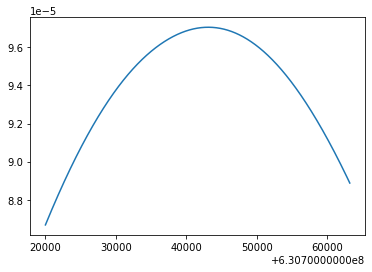

In [9]:
offset_time = np.arange(0, T_obs, 1/f_nufft)#.astype(np.longdouble)
t_space = t_eph[0] + offset_time
f_source = f_calc(f, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_eph[0]+100*offset_time), n_hat))
pl.plot(t_space, ((f_source - f_doppler)/f_source)) #Check you can see the effects

In [50]:
from scipy.integrate import cumulative_trapezoid, cumulative_simpson #otherwise very slow
phase = 2*np.pi*cumulative_trapezoid(f_doppler, dx = np.diff(t_space)[0])
signal = np.exp(1j*phase)
# test = 1/(2*np.pi)*np.gradient(phase, np.diff(t_space)[0])
# pl.plot(test)
# pl.plot(f_doppler)

ImportError: cannot import name 'cumulative_simpson' from 'scipy.integrate' (/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/scipy/integrate/__init__.py)

In [47]:
bin_no = len(signal)
bins = np.arange(bin_no) - bin_no//2

temp = (1-8/3*beta*offset_time)**(-3/8)*(1+np.dot(interp_v(t_eph[0]+100*offset_time), n_hat))
tau =  2*np.pi*cumulative_trapezoid(temp, dx = np.diff(t_space)[0])
scale = (2*pi)/(tau[-1]-tau[0])
tau *= scale
start_diff = -pi-tau[0]
tau += start_diff
nufft_amp = finufft.nufft1d1(tau.astype(np.float64), signal.astype(complex), bin_no)
nufft_freq = bins*scale/(2*pi)
nufft_power = np.abs(nufft_amp/len(signal))**2

nufft_peak = nufft_power>np.median(nufft_power)+6*np.std(nufft_power)
np.sum(nufft_power[nufft_peak])

0.9754714215305014

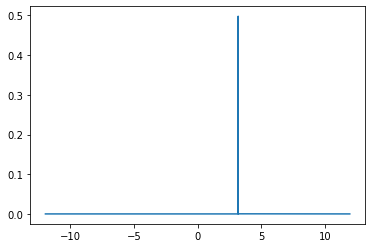

In [41]:
pl.plot(-nufft_freq, nufft_power)

In [42]:
nufft_freq[np.argmax(nufft_power)]

-3.18309722587148

In [7]:
ephemeris = np.loadtxt("earth00-40-DE440.dat", delimiter = '\t', skiprows=18)

In [8]:
[t_eph, pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, 
 acc_x, acc_y, acc_z] = ephemeris.T
v_arr = np.array([vel_x, vel_y, vel_z])
acc_arr = np.array([acc_x, acc_y, acc_z])

interp_v = CubicSpline(t_eph, v_arr.T)
interp_acc = CubicSpline(t_eph, acc_arr.T)

In [ ]:
H_lat = 119.41 * np.pi/180 # rad
H_lng = 46.45 * np.pi/180 # rad

params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = H_lat, 
              lng = H_lng, az = 0.5)

n_hat = (np.cos(params['ra'])*np.cos(params['dec']),
        np.sin(params['ra'])*np.cos(params['dec']),
        np.sin(params['dec']))

In [10]:
def f_calc(f0, beta, t):
    return f0*(1-8/3*beta*t)**(-3/8)

def phi_calc(f0, beta, t):
    return -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta

In [11]:
H_lat = 119.41 * np.pi/180 # rad
H_lng = 46.45 * np.pi/180 # rad

params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = H_lat, 
              lng = H_lng, az = 0.5)

n_hat = (np.cos(params['ra'])*np.cos(params['dec']),
        np.sin(params['ra'])*np.cos(params['dec']),
        np.sin(params['dec']))

f0 = 10
Mc = 1e-3 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)

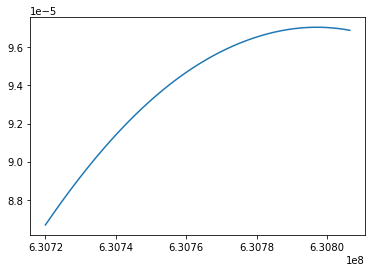

In [19]:
# Using t=30 days for long enough to see Doppler effects
offset_arr = np.linspace(0, 1*day, int(1e5))
t_space = t_eph[0] + offset_arr
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_eph[0]+30*offset_arr), n_hat))
pl.plot(t_space, ((f_source - f_doppler)/f_source)) #Check you can see the effects

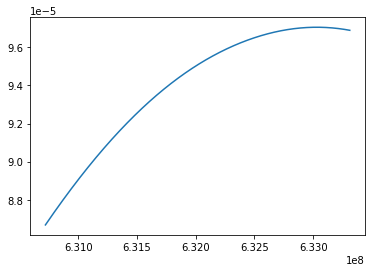

In [17]:
# Using t=30 days for long enough to see Doppler effects
offset_arr = np.linspace(0, 30*day, int(1e5))
t_space = t_eph[0] + offset_arr
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
pl.plot(t_space, ((f_source - f_doppler)/f_source)) #Check you can see the effects

In [96]:
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0]
phi_approx = phi_source * (1+np.dot(interp_v(t_space), n_hat))
f_approx  = 1/(2*pi)*np.gradient(phi_approx, np.diff(t_space)[0])

temp = -np.dot(interp_acc(t_space), n_hat)*phi_source
correction = [np.trapz(temp[:i], dx=np.diff(t_space)[0]) for i in range(len(temp))]
test0 = phi_approx + correction
test1 = 1/(2*pi)*np.gradient(test0, np.diff(t_space)[0])

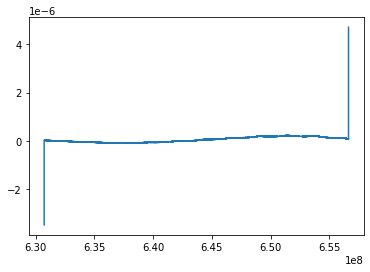

In [98]:
# pl.plot(t_space, (f_doppler - f_approx))
pl.plot(t_space, f_doppler - test1)

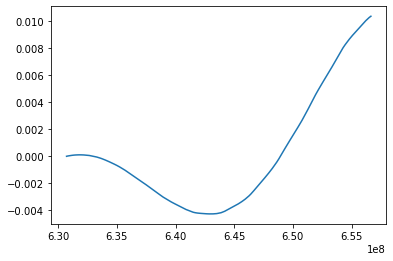

In [72]:
pl.plot(t_space, (f_doppler - f_approx))

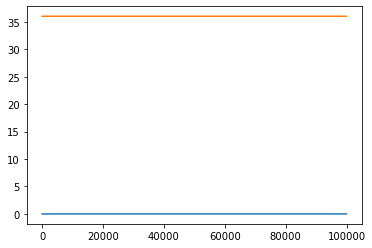

In [20]:
pl.plot(np.dot(interp_v(t_space), n_hat))
pl.plot(np.dot(interp_v(t_space)-interp_v(0), n_hat))

## Debugging

In [42]:
# Time derivative of velocity is correctly small
# %matplotlib notebook
# pl.plot(t_eph, np.dot(acc_arr.T, n_hat))
# pl.plot(t_space[:-1], np.diff(np.dot(interp_v(t_space), n_hat))/np.diff(t_space))

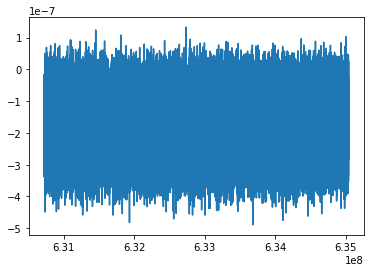

In [43]:
# The same up to numerical noise
%matplotlib inline
pl.plot(t_space[:-1], f_source[:-1] - 1/(2*np.pi)*np.diff(phi_source)/np.diff(t_space))

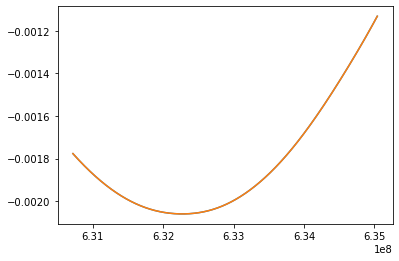

In [44]:
# The same up to numerical noise
pl.plot(t_space[:-1], 1/(2*np.pi)*\
        np.diff(phi_source*np.dot(interp_v(t_space), n_hat)-\
        np.dot(interp_acc(t_space), n_hat))/np.diff(t_space))

pl.plot(t_space, f_source*np.dot(interp_v(t_space), n_hat) + phi_source/(2*np.pi)*np.dot(interp_acc(t_space), n_hat))

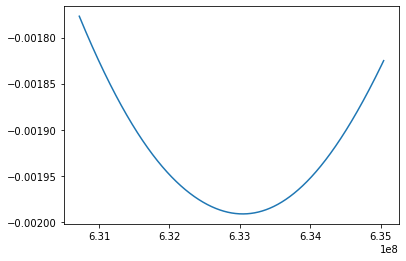

In [47]:
pl.plot(t_space, f_source*np.dot(interp_v(t_space), n_hat))

In [50]:
test0 = 1/(2*pi)*np.diff(phi_calc(f0, beta, t_eph-t_eph[0]))/np.diff(t_eph)
test1  = 1/(2*pi)*np.diff(phi_approx)/np.diff(t_eph)
pl.plot(t_eph[:-1], (test0 - test1))

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in power
  """


ValueError: operands could not be broadcast together with shapes (99999,) (175321,) 

In [51]:
pl.plot(t_eph[:-1], (f_doppler[:-1] - test1))

NameError: name 'test1' is not defined

In [52]:
pl.plot(t_eph, signal_approx - signal_doppler)

NameError: name 'signal_approx' is not defined

In [53]:
from scipy import integrate
def exact(index):
    return integrate.trapezoid(f_test[:index], (t_eph-t_eph[0])[:index])

In [25]:
f_test = f_doppler[np.isfinite(f_doppler)]
t_test = t_eph[np.isfinite(f_doppler)]
idx_space = np.arange(len(f_test))+1
exact_phase = np.array([exact(i) for i in idx_space])

phi_approx = phi_calc(f0, beta, t_eph-t_eph[0])*(1+np.dot(v_arr.T, n_hat))
phi_approx -= phi_approx[0]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 175322 but corresponding boolean dimension is 100000

## Approx Doppler

In [26]:
def t_side(time, long):
    tsid=time/0.9972695667+(100.18+long)/360;
    tsid=tsid-np.floor(tsid);
    return tsid

In [27]:
def earth_v0(time, long, lat):
    tsid=t_side(time,long)*2*pi;
    tanno=time/365.25;
    tanno=np.mod(tanno,1)*2.*pi;
    
    vrot=1.5514066e-6*np.cos(lat*0.01745329);
    vorb=9.9302031e-5;
    sineps=0.397948;
    coseps=0.917407;
    sinlam=np.sin(tanno);
    coslam=np.cos(tanno);

    zo=sineps*sinlam;
    czo=np.sqrt(1-zo*zo);
    xo=coslam*czo;
    yo=sinlam*czo;

    xr=np.cos(tsid);
    yr=np.sin(tsid);

    x=vrot*xr+vorb*xo;
    y=vrot*yr+vorb*yo;
    z=vorb*zo;

    v=np.sqrt(x*x+y*y+z*z);
    alf=np.arctan2(y,x);
    delt=np.arcsin(z/v);
    return alf, delt, v

In [28]:
day = 86400
t_space = np.linspace(0, 3*day, int(1e4))
ae,de,v = earth_v0(t_space, H_lng, H_lat)

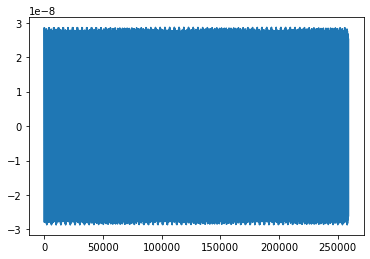

In [29]:
pl.plot(t_space[:-1], np.diff(v)/np.diff(t_space))

In [30]:
f0 = 20
ra = params['ra']
dec = params['dec']
cosfi=(np.cos(ra)*np.cos(ae)+np.sin(ra)*np.sin(ae))*np.cos(dec)*np.cos(de)+np.sin(dec)*np.sin(de);

f_doppler=f0*(1+cosfi*v);

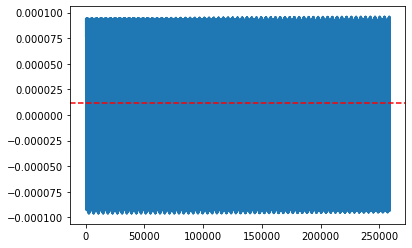

In [31]:
pl.plot(t_space, (cosfi*v))
pl.axhline(1/(1*day), c='r', ls='--')

In [32]:
1/(1*day)

1.1574074074074073e-05